### Scales & appearance
Edit the numbers marked `👈` and re-run.

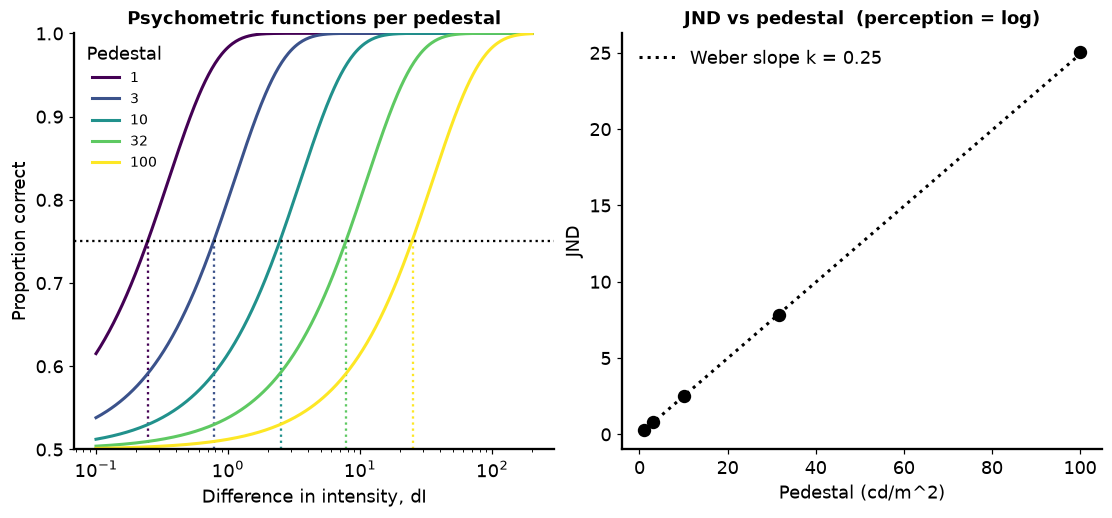

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# How does the just-noticeable difference (JND) depend on the baseline intensity
# (the "pedestal")? It depends on how perceived intensity scales with the stimulus.
pedestals  = np.array([1.0, 3.16, 10.0, 31.6, 100.0])   # cd/m^2 (log-spaced)
delta_I    = np.logspace(-1, 2.3, 400)                  # differences to test
perception = "log"     # 👈 "log", "linear", or "power"
noise_frac = 0.05      # 👈 perceptual noise (as a fraction of the perceptual range)

def f(I):
    if perception == "log":    return np.log(I)
    if perception == "linear": return I
    return I ** 0.7            # power

sigma = noise_frac * (f(pedestals.max()) - f(pedestals.min()))
colours = plt.cm.viridis(np.linspace(0, 1, pedestals.size))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True)
jnds = []
for pi, ped in enumerate(pedestals):
    # 2AFC proportion correct: did pedestal+delta feel stronger than pedestal?
    pc = norm.cdf((f(ped + delta_I) - f(ped)) / (sigma * np.sqrt(2)))
    axL.plot(delta_I, pc, color=colours[pi], lw=2, label=f"{ped:.0f}")
    jnd = delta_I[np.argmax(pc >= 0.75)]      # JND = smallest delta reaching 75%
    jnds.append(jnd)
    axL.plot([jnd, jnd], [0.5, 0.75], color=colours[pi], ls=":")
axL.axhline(0.75, color="k", ls=":")
axL.set(xscale="log", xlabel="Difference in intensity, dI", ylabel="Proportion correct",
        ylim=(0.5, 1), title="Psychometric functions per pedestal")
axL.legend(title="Pedestal", fontsize=9)

jnds = np.array(jnds)
axR.scatter(pedestals, jnds, 60, color="k", zorder=3)
weber = np.mean(jnds / pedestals)
axR.plot(pedestals, pedestals * weber, "k:", lw=2, label=f"Weber slope k = {weber:.2f}")
axR.set(xlabel="Pedestal (cd/m^2)", ylabel="JND", title=f"JND vs pedestal  (perception = {perception})")
axR.legend()
plt.show()
